In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# Set Chinese font family when available
# On Linux you can try fonts such as:
# 'DejaVu Sans', 'WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'SimHei'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'WenQuanYi Micro Hei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

findfont: Generic family 'sans-serif' not found because none of the following families were found: Heiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: Heiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: Heiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: Heiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: Heiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: Heiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: Heiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: Heiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: Heiti
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Heiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: Heiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: Heiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: Heiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: Heiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: Heiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: Heiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: Heiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: Heiti
findfont: Generic family 'sans-serif' not found because

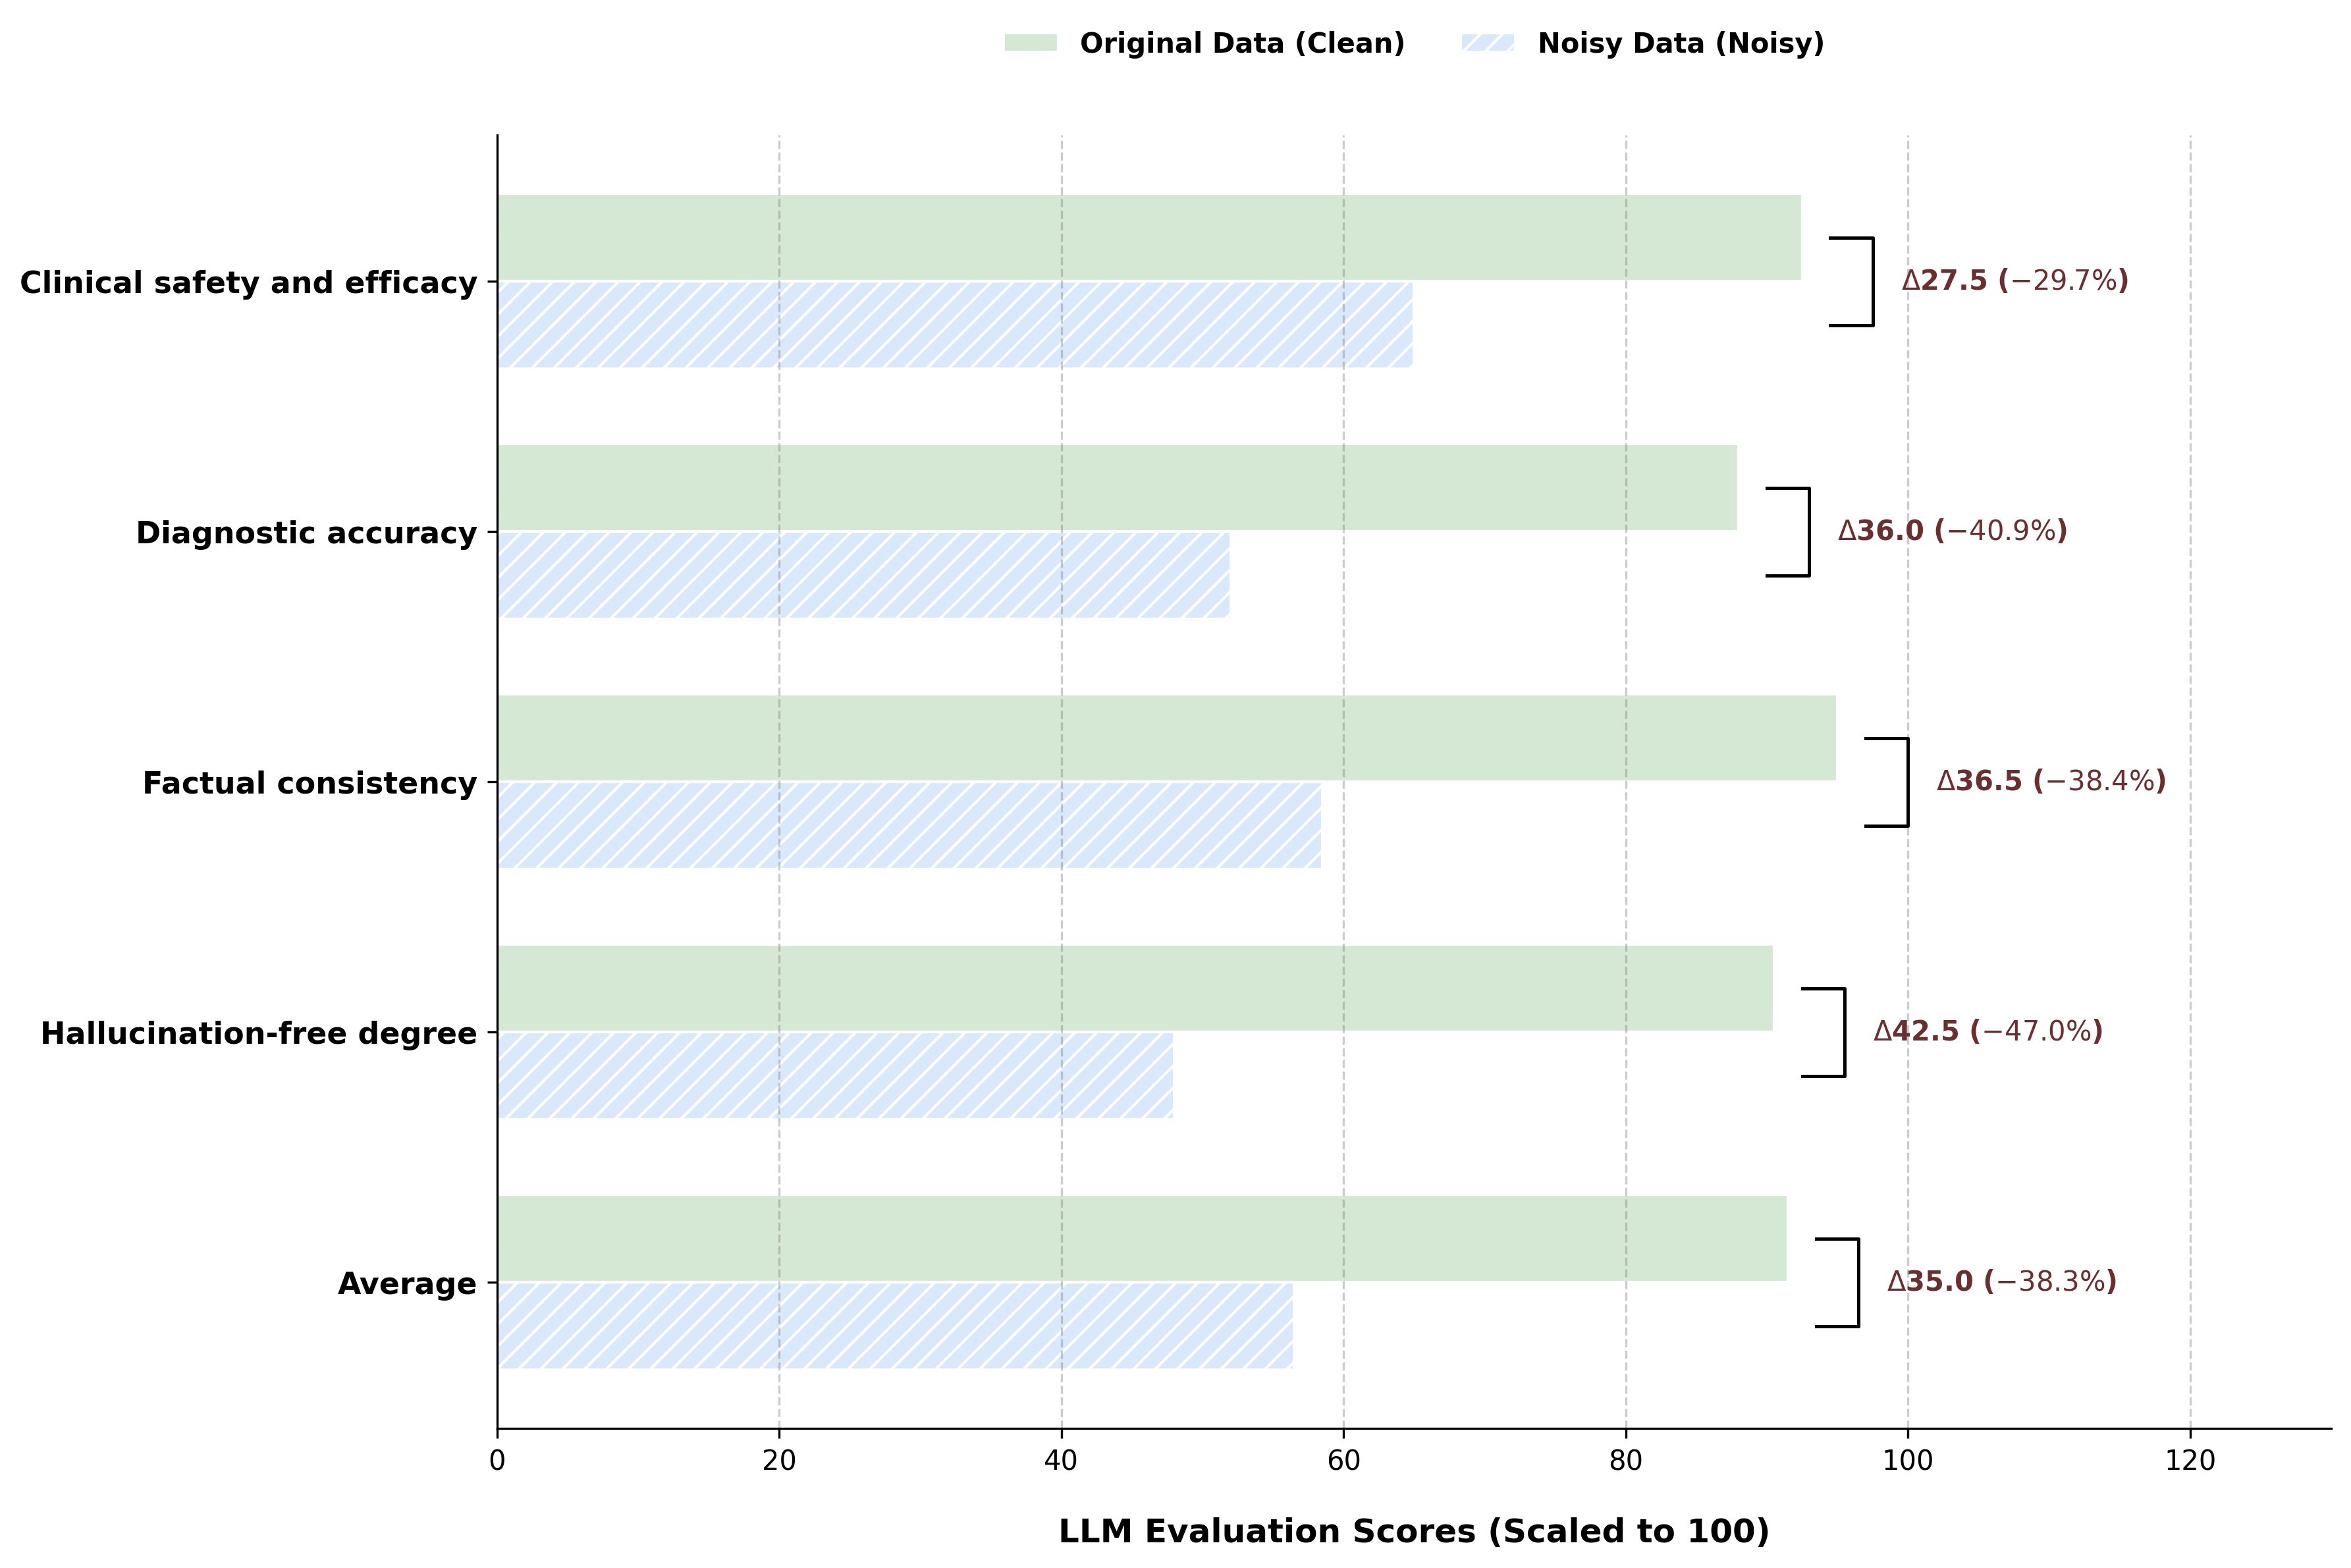

In [3]:


# 设置中文字体（根据环境可调整，如 'SimHei' 或 'Heiti TC'）
plt.rcParams['font.sans-serif'] = ['Heiti'] 
plt.rcParams['axes.unicode_minus'] = False

# 准备实验数据
# categories = ["临床安全性", "辩证准确性", "事实一致性", "无幻觉程度", "平均值"]
categories = ["Clinical safety and efficacy", "Diagnostic accuracy", "Factual consistency", "Hallucination-free degree", "Average"]
clean_scores = [92.5, 88.0, 95.0, 90.5, 91.5]
noisy_scores = [65.0, 52.0, 58.5, 48.0, 56.5]

# # 绘图参数设置
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)  # 增大尺寸，提高DPI
bar_height = 0.35
index = np.arange(len(categories))

# 绘制水平条形图
# 蓝色代表 Clean，橙色带斜纹代表 Noisy
bars_clean = ax.barh(index, clean_scores, bar_height, 
                    label='Original Data (Clean)', color='#D5E8D4', edgecolor='white')
bars_noisy = ax.barh(index + bar_height, noisy_scores, bar_height, 
                    label='Noisy Data (Noisy)', color='#DAE8FC', hatch='///', edgecolor='white')

# 美化坐标轴
ax.set_xlabel('LLM Evaluation Scores (Scaled to 100)', fontsize=12, fontweight='bold', labelpad=15)
ax.set_yticks(index + bar_height / 2)
ax.set_yticklabels(categories, fontsize=11, fontweight='bold')
ax.set_xlim(0, 130)  # 预留空间给右侧标注
ax.invert_yaxis()    # 反转 y 轴，让第一个指标在最上面
ax.xaxis.grid(True, linestyle='--', alpha=0.4, color='gray') # 垂直网格线
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 添加差值和大括号标注 ($\Delta$ 和 %)
for i in range(len(categories)):
    c_val = clean_scores[i]
    n_val = noisy_scores[i]
    delta = c_val - n_val
    percent_drop = (delta / c_val) * 100
    
    # 计算标注位置
    bracket_x = max(c_val, n_val) + 2
    y_mid = i + bar_height / 2
    
    # 绘制模拟大括号的线条
    ax.plot([bracket_x, bracket_x + 3, bracket_x + 3, bracket_x], 
            [i, i, i + bar_height, i + bar_height], color='black', lw=1.2)
    
    # 添加文本标注
    text = f"$\Delta${delta:.1f} ($-{percent_drop:.1f}\%$)"
    ax.text(bracket_x + 5, y_mid, text, va='center', fontsize=10, 
            color='#6b2e31', fontweight='bold')

# 添加图例
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=2, 
          frameon=False, fontsize=12, prop={'weight':'bold'})

plt.tight_layout()
plt.savefig('tcm_eval_chart.png', dpi=300)
plt.show()